In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [10]:
def fcours(x):
  f = 2*x-np.log(x)
  g = 2 - 1/x
  H = 1/(x**2)
  return f, g, H

def fcours2(x):
  f = x**3 - 6*x**2 + 4*x + 12
  g = 3*x**2 - 12*x + 4
  H = 6*x - 12
  return f, g, H

In [11]:
def newtonOPTILIN(fct, x0, maxiter, tol=1e-9):
  x = np.zeros(maxiter)
  x[0] = x0

  for k in range(maxiter-1):
    f, g, H = fct(x[k])
    x[k+1] = x[k] - g/H   # Attention, H est scalaire dans ce cas ci
    print(f"Itéré {k+1} : x = {x[k+1]} et f'(x) = {g}")
  return x

Itéré 1 : x = 0.18000000000000002 et f'(x) = -8.0
Itéré 2 : x = 0.2952 et f'(x) = -3.5555555555555545
Itéré 3 : x = 0.41611392 et f'(x) = -1.3875338753387534
Itéré 4 : x = 0.4859262511644672 et f'(x) = -0.4031880500416807
Itéré 5 : x = 0.4996038591874286 et f'(x) = -0.05792545186355591
Itéré 6 : x = 0.49999968614491325 et f'(x) = -0.0015858196660678558
Itéré 7 : x = 0.499999999999803 et f'(x) = -1.2554211350490618e-06
Itéré 8 : x = 0.5 et f'(x) = -7.882583474838611e-13


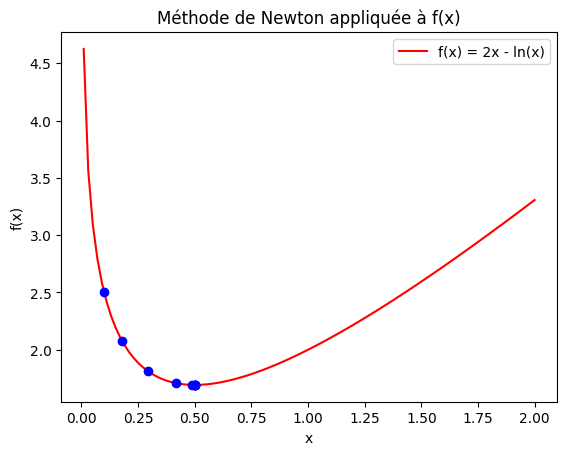

In [12]:
x0 = 0.1
maxiter = 9
x = newtonOPTILIN(fcours, x0, maxiter)

# Tracé de la fonction f et des itérés de Newton
absc = np.linspace(0.01, 2, 100)
ordo = fcours(absc)[0]
plt.plot(absc, ordo, 'red', label="f(x) = 2x - ln(x)")

for k in range(len(x)):
    f, g, H = fcours(x[k])
    plt.plot(x[k], f, 'bo')  # Itérés en bleu

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Méthode de Newton appliquée à f(x)")
plt.show()

Itéré 1 : x = 0.3482456140350877 et f'(x) = 2.83
Itéré 2 : x = 0.3669002897578518 et f'(x) = 0.1848776546629729
Itéré 3 : x = 0.3670068346687777 et f'(x) = 0.0010439907789647762
Itéré 4 : x = 0.3670068381445479 et f'(x) = 3.405545356827133e-08
Itéré 5 : x = 0.367006838144548 et f'(x) = 8.881784197001252e-16
Itéré 6 : x = 0.3670068381445479 et f'(x) = -8.881784197001252e-16
Itéré 7 : x = 0.367006838144548 et f'(x) = 8.881784197001252e-16
Itéré 8 : x = 0.3670068381445479 et f'(x) = -8.881784197001252e-16


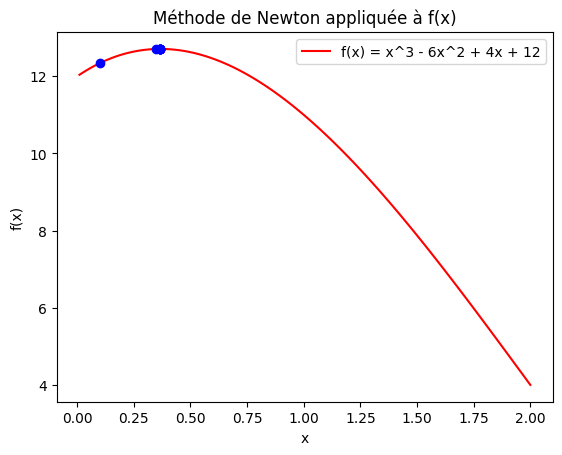

In [13]:
x0 = 0.1
maxiter = 9
x = newtonOPTILIN(fcours2, x0, maxiter)

# Tracé de la fonction f et des itérés de Newton
absc = np.linspace(0.01, 2, 100)
ordo = fcours2(absc)[0]
plt.plot(absc, ordo, 'red', label="f(x) = x^3 - 6x^2 + 4x + 12")

for k in range(len(x)):
    f, g, H = fcours2(x[k])
    plt.plot(x[k], f, 'bo')  # Itérés en bleu

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Méthode de Newton appliquée à f(x)")
plt.show()

In [14]:
def fsize(x,nargout=2):
  n = len(x)

  #Calcul de f
  v      = 1.0*x
  v[:-1] = v[:-1]-x[1:]*np.arange(2,1+len(x))
  v[-1]  = x[-1]-x[0]-1
  f      = np.sum(v**4)

  #Calcul du gradient uniquement s'il est demandé
  g     = 4*v**3
  g[1:] = g[1:]-4*(v[:-1]**3)*np.arange(2,1+len(x))
  g[0]  = g[0]-4*v[-1]**3

  #Calcul de la hessienne uniquement si elle est demandée
  if nargout==3:
    H = np.zeros((n,n))
    for i in range(1,n):
      H[i-1:i+1,i-1:i+1] = H[i-1:i+1,i-1:i+1]+ 12*v[i-1]**2*np.array([[1,-(i+1)],[-(i+1),(i+1)**2]])
    H[0,0]   += 12*v[-1]**2
    H[0,-1]  -= 12*v[-1]**2
    H[-1,0]  -= 12*v[-1]**2
    H[-1,-1] += 12*v[-1]**2
  if nargout==3:
    return f, g, H
  else:
    return f, g

In [15]:
def gradientTIME(fct, x0, maxiter, maxtime):
  start_time = time.time()
  x = x0.copy()

  fobj = np.zeros(maxiter)
  temps = np.zeros(maxiter)

  for k in range(maxiter):

    f, g = fct(x)
    alpha = 1.0
    f, g = fct(x, nargout=3)
    alpha = 1.0
    z = np.lindiag.solve(f,g)   # O(n^3)
    x = x - alpha*z   # Calcul du nouvel itéré
    fobj[k] = f
    temps[k] = time.time() - start_time

    if temps[k] > maxtime:
      break
  return x, fobj[:k], temps[:k]

In [16]:
def newtonTIME(fct, x0, maxiter, maxtime):
  start_time = time.time()
  x = x0.copy()

  fobj = np.zeros(maxiter)
  temps = np.zeros(maxiter)

  for k in range(maxiter):
    f, g, H = fct(x, nargout=3)
    alpha = 1.0
    z = np.lindiag.solve(f,g)   # O(n^3)
    x = x - alpha*z   # Calcul du nouvel itéré
    fobj[k] = f
    temps[k] = time.time() - start_time

    if temps[k] > maxtime:
      break
  return x, fobj[:k], temps[:k]